In [68]:
import ogbench
import gymnasium
import matplotlib.pyplot as plt

In [69]:
env, train, test = ogbench.make_env_and_datasets('antmaze-large-navigate-v0', dataset_dir='datasets/', env_only=False)

In [70]:
train.keys(), test.keys()

(dict_keys(['observations', 'actions', 'terminals', 'next_observations']),
 dict_keys(['observations', 'actions', 'terminals', 'next_observations']))

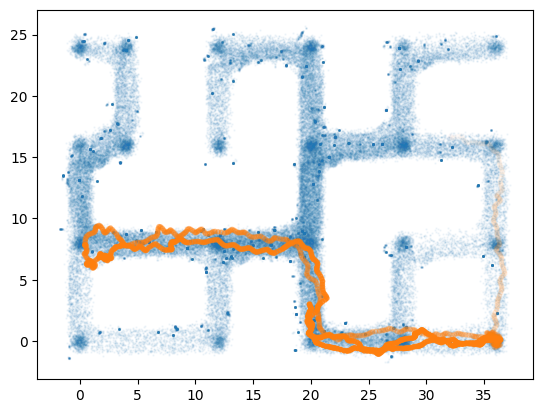

In [75]:
x = train['observations'][::10, :2]
plt.scatter(x[:, 0], x[:, 1], s=0.5, alpha=0.05)

i = 15
x = train['observations'].reshape(-1, 1000, 29)
# x = x[(x[:, 0, 0] < 21) & (x[:, 0, 0] > 19) & (x[:, 0, 1] < 16) & (x[:, 0, 1] > 14)]
plt.scatter(x[i, :, 0], x[i, :, 1], s=10, alpha=list([i / 1000 for i in range(1000)]))

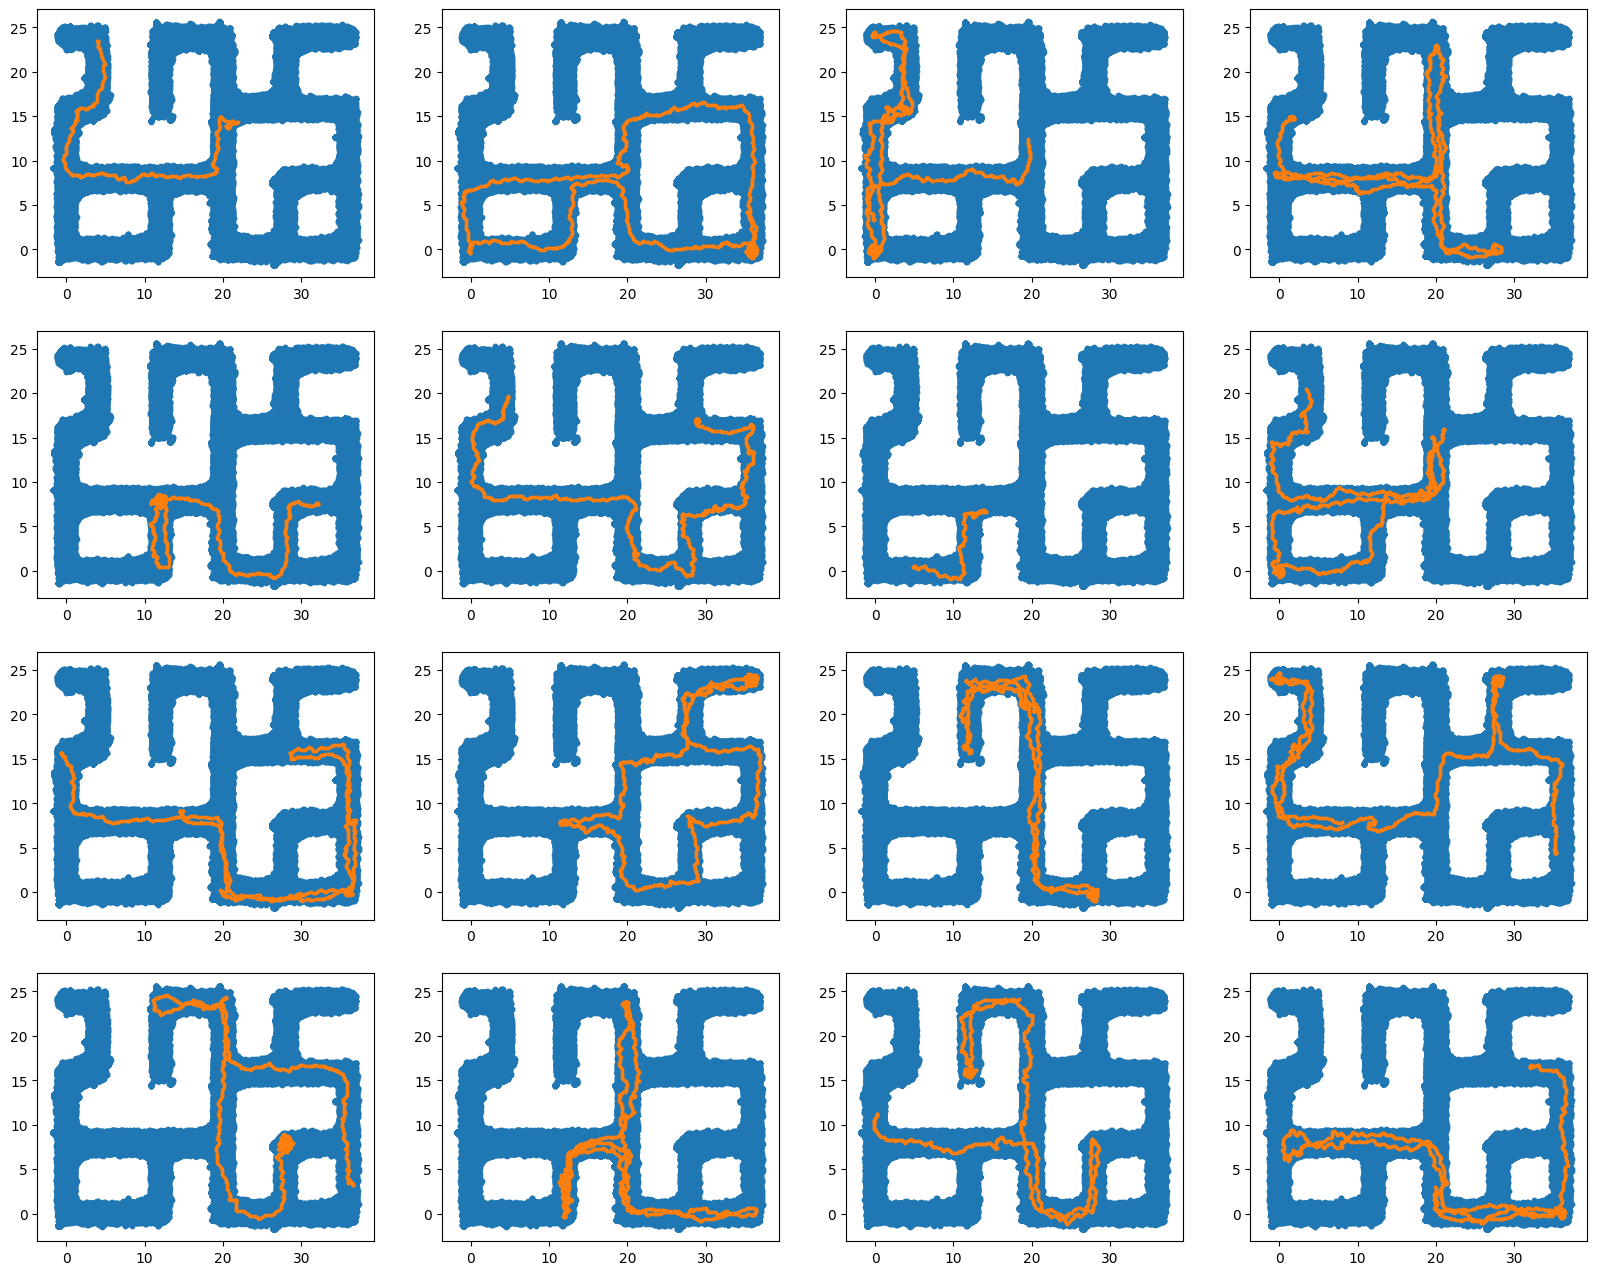

In [76]:
fig, axs = plt.subplots(4, 4, figsize=(20, 16))
axs = axs.flatten()

for i in range(len(axs)):
    axs[i].scatter(x[:,:, 0], x[:,:, 1], s=10)
    axs[i].scatter(x[i, :, 0], x[i, :, 1], s=3)
plt.show()

In [73]:
# env.unwrapped.
dataset_name = 'antmaze-large-navigate-v0'
splits = dataset_name.split('-')
print(splits)
env_name = '-'.join(splits[:-2] + splits[-1:])  # Remove the dataset type.
# env = gymnasium.make(env_name)

['antmaze', 'large', 'navigate', 'v0']


In [47]:
state, info = env.reset()

In [54]:
env.unwrapped

<ogbench.locomaze.maze.make_maze_env.<locals>.MazeEnv at 0x7e3f04362680>

In [52]:
state

array([ 1.20954234e+01,  2.40402570e+01,  7.63592071e-01,  9.99633607e-01,
       -5.23793244e-02, -4.50643269e-02,  4.64088685e-02,  1.81873928e-03,
       -3.89333782e-02, -4.55622010e-02,  5.08391955e-02, -1.19519297e-02,
       -2.25846554e-02, -9.37840448e-02,  9.88017932e-02,  2.56777857e-02,
        6.22153062e-02, -4.01418470e-03, -1.03861098e-01,  4.58236935e-02,
       -3.12931862e-02,  5.01069094e-02,  4.29378173e-03,  2.26290463e-01,
        1.95388501e-02, -1.56159527e-01, -1.89744200e-02, -1.59247035e-01,
        5.11573089e-02])

---

In [41]:
import numpy as np
import minari

dataset = minari.load_dataset('D4RL/antmaze/large-diverse-v1', download=True)


In [42]:
env = dataset.recover_environment()

/home/nazim/.local/lib/python3.10/site-packages/minari/dataset/minari_dataset.py:204: UserWarning: Installed mujoco version 3.3.2 does not meet the requirement <=3.1.6,>=3.1.1.
We recommend to install the required version with `pip install "mujoco>=3.1.1,<=3.1.6"`
  warnings.warn(


In [44]:
res = []
for _ in range(1000):
    info = env.reset()
    start = info[0]['achieved_goal']
    res.append(start)
    
res = np.stack(res)
res[..., 1] = -res[..., 1]

In [45]:
space = np.concatenate([dataset[i].observations['achieved_goal'] for i in range(len(dataset))]).reshape(1000, 1001, 2)
space[..., 1] = -space[..., 1]

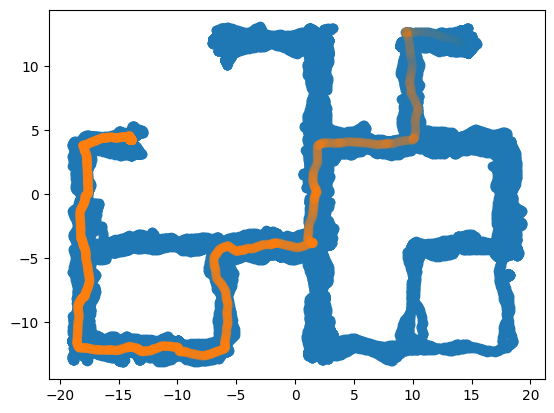

In [60]:
_ = plt.scatter(space[::10, :, 0], space[::10, :, 1], alpha=1)

# plt.scatter(res[:, 0], res[:, 1])

i = 10
plt.scatter(space[i, :, 0], space[i, :, 1], alpha=list([n/1001 for n in range(1001)]))

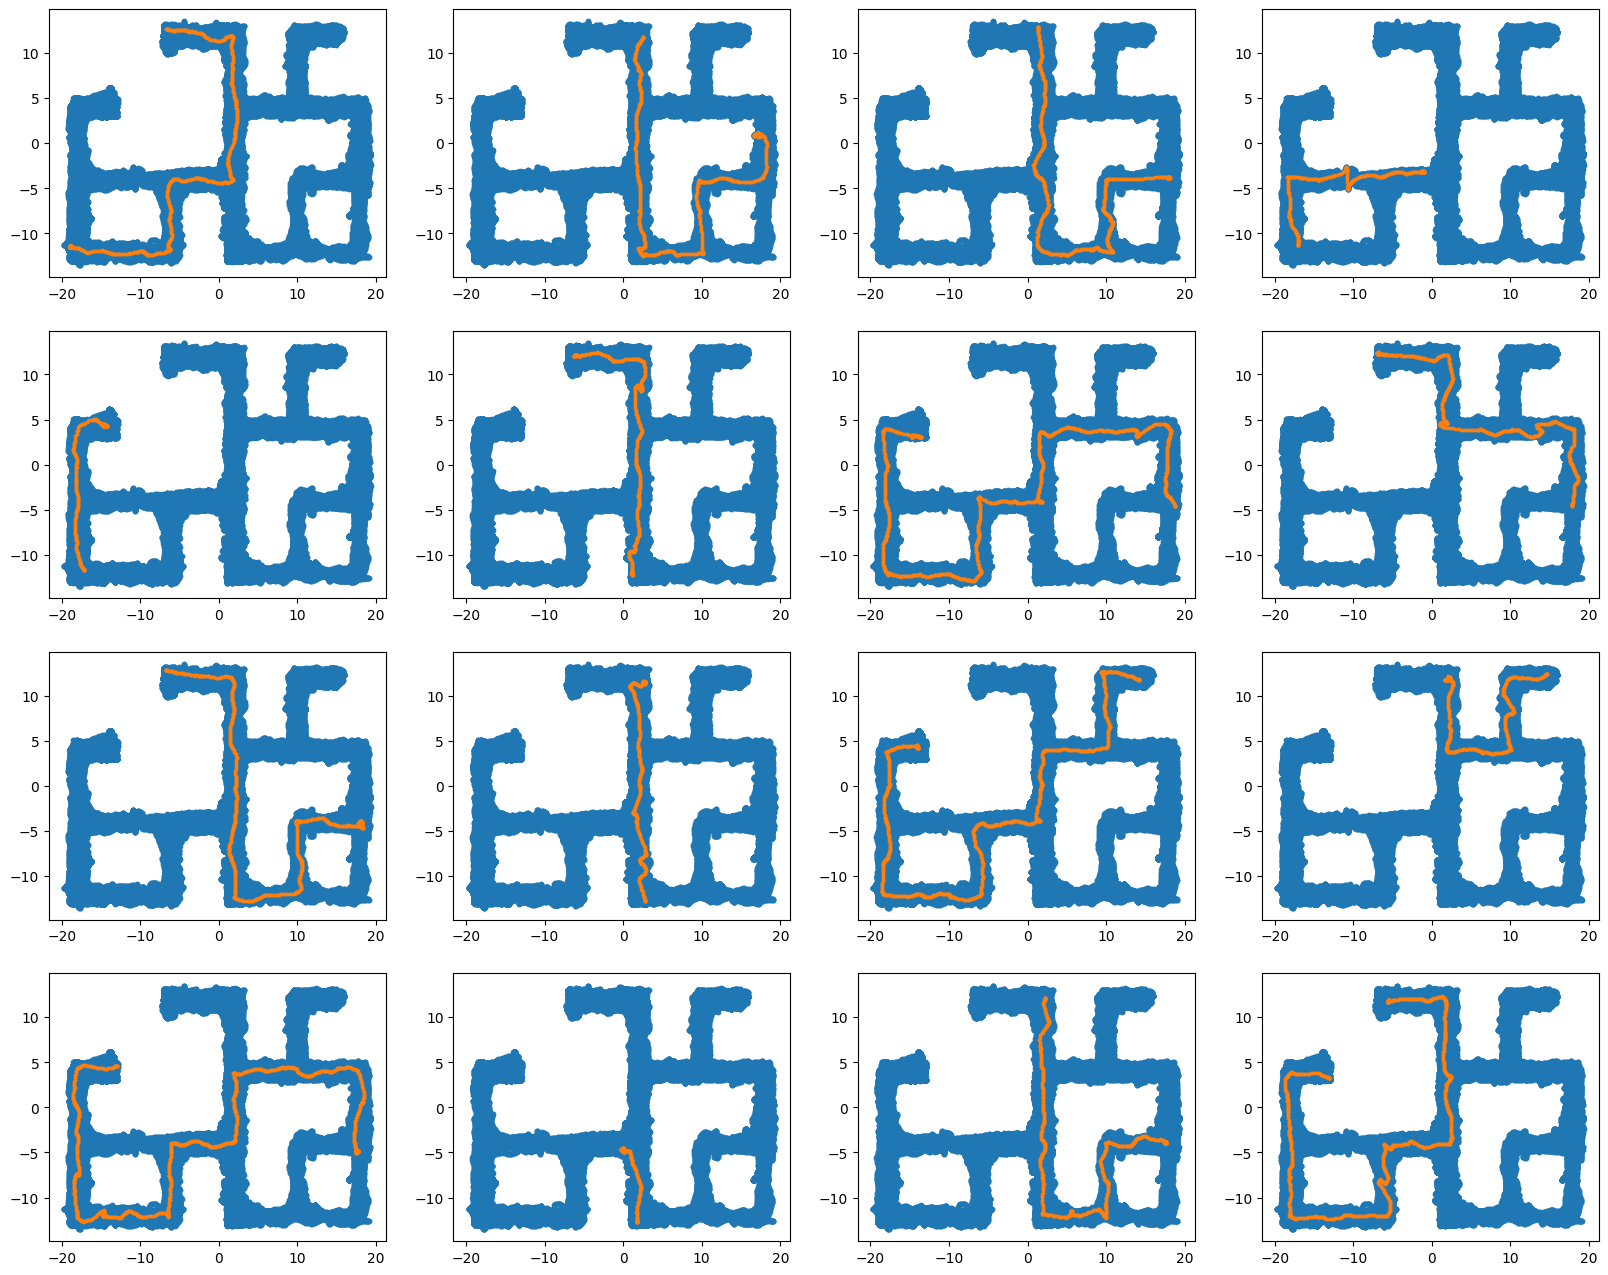

In [67]:
fig, axs = plt.subplots(4, 4, figsize=(20, 16))
axs = axs.flatten()

for i in range(len(axs)):
    axs[i].scatter(space[:,:, 0], space[:,:, 1], s=10)
    axs[i].scatter(space[i, :, 0], space[i, :, 1], s=3)
plt.show()

---

In [62]:
import gym
import d4rl # Import required to register environments, you may need to also import the submodule
import matplotlib.pyplot as plt

# Create the environment
env = gym.make('antmaze-large-diverse-v2')

# d4rl abides by the OpenAI gym interface
# env.reset()
# env.step(env.action_space.sample())

# Each task is associated with a dataset
# dataset contains observations, actions, rewards, terminals, and infos
dataset = env.get_dataset()

/home/nazim/.local/lib/python3.10/site-packages/gym/spaces/box.py:84: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Target Goal:  (33.232841319481885, 24.128840310760644)


load datafile: 100%|██████████| 8/8 [00:01<00:00,  5.56it/s]


In [5]:
dataset['observations'].shape

(1000000, 29)

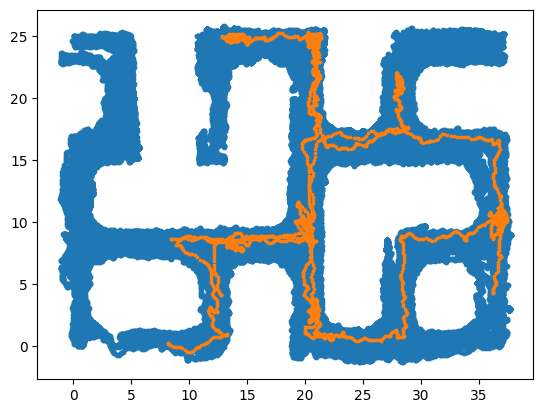

In [40]:
x = dataset['infos/qpos'][:, :2].reshape(1000, 1000, 2)

plt.scatter(x[:,:, 0], x[:,:, 1], s=10)


# plt.scatter(x[:, 0, 0], x[:, 0, 1])
i = 6
plt.scatter(x[:i, :, 0], x[:i, :, 1], s=3)

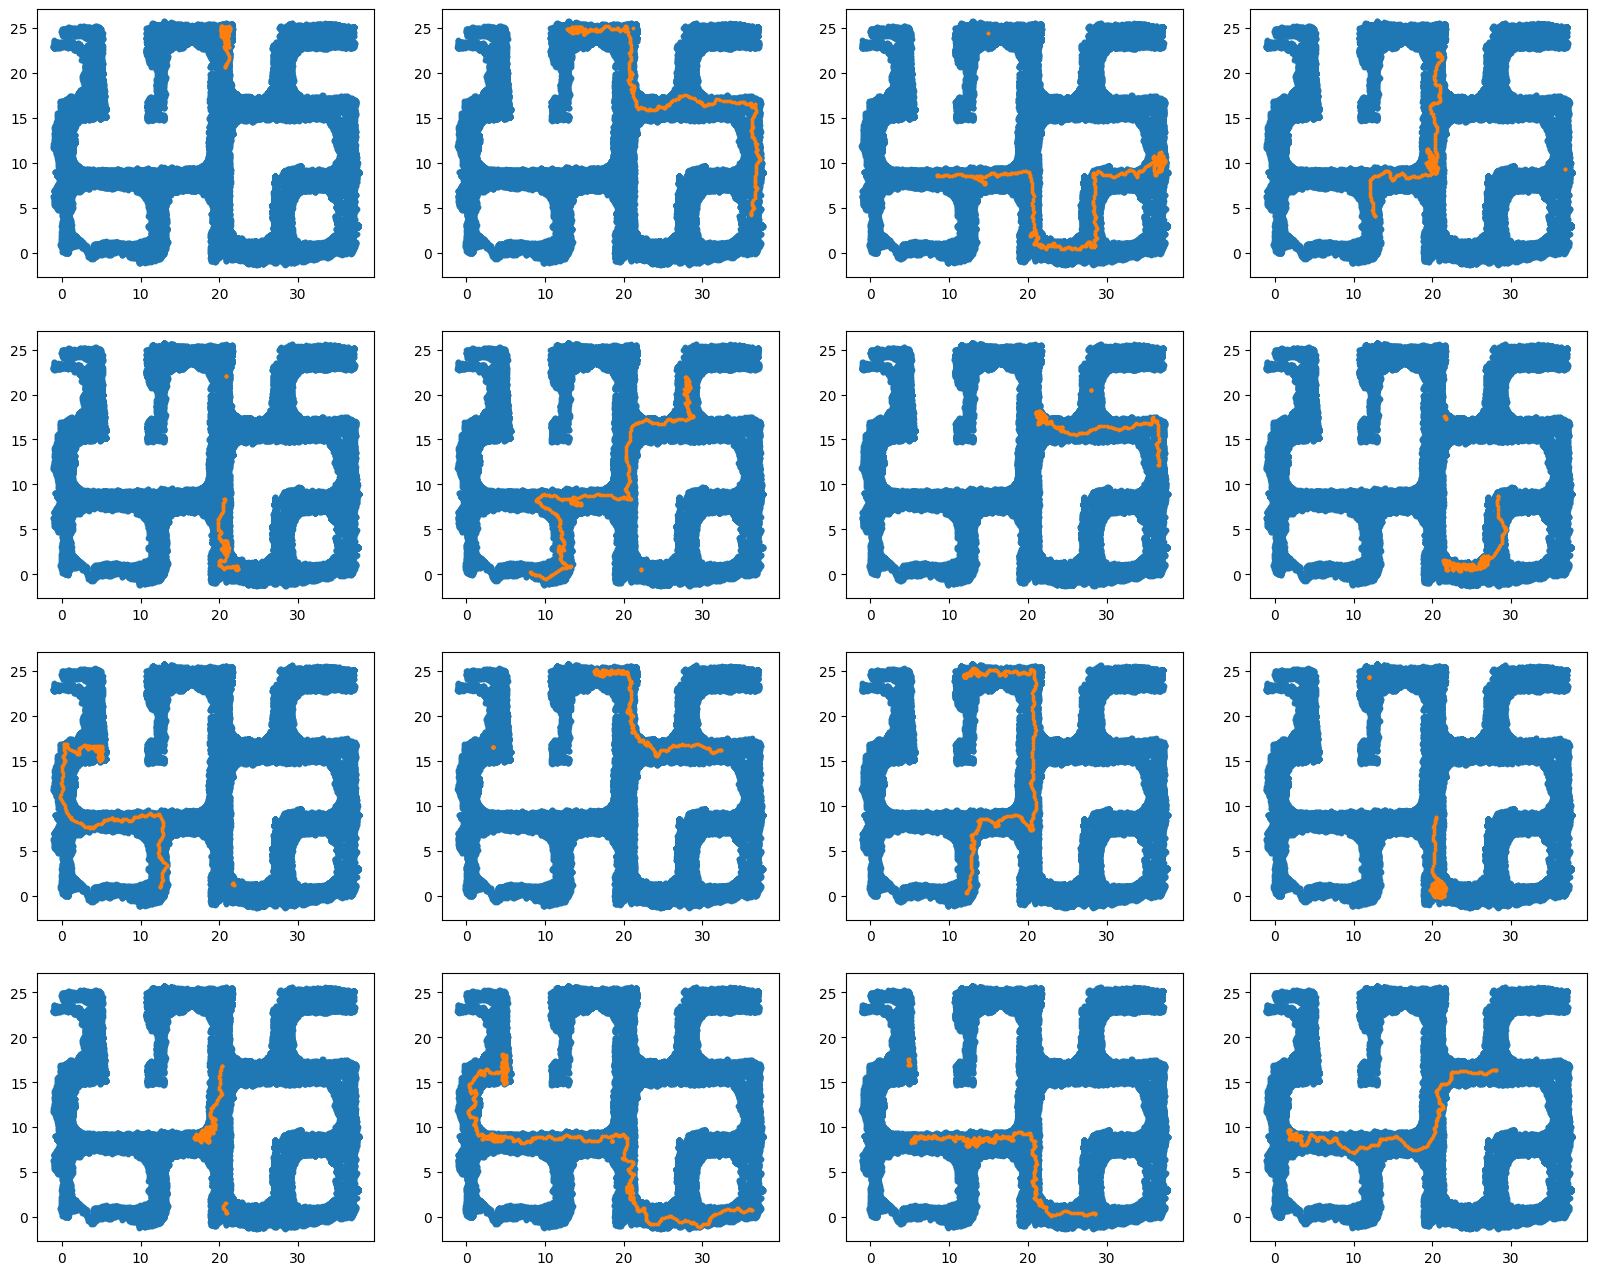

In [66]:
x = dataset['infos/qpos'][:, :2].reshape(1000, 1000, 2)

fig, axs = plt.subplots(4, 4, figsize=(20, 16))
axs = axs.flatten()

for i in range(len(axs)):
    axs[i].scatter(x[:,:, 0], x[:,:, 1], s=10)
    axs[i].scatter(x[i, :, 0], x[i, :, 1], s=3)
plt.show()